In [1]:
from daily_report_v2 import *
from my_fun.my_fun import compute_window, save_notebook_files
from plotting_style import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [16]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'png'
# %config InlineBackend.figure_format = 'retina'

In [4]:
# Load data
subject = '333'
path_sessions = Path.home() / 'PycharmProjects' / 'glue_sessions' / '2AFC_2' / f'{subject}.csv'
df = pd.read_csv(path_sessions)
path_intersession = Path.home() / 'PycharmProjects' / 'intersession' / '2AFC_2' / f'{subject}_intersession.csv'
df_inter = pd.read_csv(path_intersession)

C:\Users\Usuario\anaconda3\envs\glmhmm\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (24) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [5]:
# Filter data
# df = df[df.Miss == 0].reset_index(drop=True)  # Need to plot miss rate
df = df[df.CB == 0].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)
df = df[df.P == 0.5].reset_index(drop=True)

dates = df.Date.unique()
df_inter = df_inter[df_inter['Dates'].isin(dates)]
df_inter.Accuracy.describe()

count    37.000000
mean      0.798577
std       0.107333
min       0.483871
25%       0.789127
50%       0.835443
75%       0.863281
max       0.911330
Name: Accuracy, dtype: float64

In [6]:
threshold_center = 0.75
threshold_tolerance = 0.1
threshold_edges = (threshold_center - threshold_tolerance, threshold_center + threshold_tolerance)
threshold_edges = (0.5, 1)  # More permissive

# Drop any rows in df_inter where Accuracy, AccuracyLeft, or AccuracyRight is < 0.5. Count them
df_inter = df_inter[
    (df_inter.Accuracy >= threshold_edges[0]) &
    (df_inter.AccuracyLeft >= threshold_edges[0]) &
    (df_inter.AccuracyRight >= threshold_edges[0]) &
    (df_inter.Accuracy <= threshold_edges[1]) &
    (df_inter.AccuracyLeft <= threshold_edges[1]) &
    (df_inter.AccuracyRight <= threshold_edges[1])
]

# Drop sessions in df that are not in df_inter
dates = df_inter['Dates'].unique()
df = df[df['Date'].isin(dates)].reset_index(drop=True)

In [7]:
# Lists to store results
running_acc_total = []
running_acc_left = []
running_acc_right = []

for session_id, df_session in df.groupby('Session'):
    n_trials = len(df_session)

    # Total running accuracy
    ra_total = compute_window(df_session['Hit'].values)  # default win_length=20
    running_acc_total.extend(ra_total)

    # Left running accuracy
    left_array = np.full(n_trials, np.nan)
    left_idx = df_session['Side'] == 0
    left_array[left_idx] = compute_window(df_session.loc[left_idx, 'Hit'].values)
    running_acc_left.extend(left_array)

    # Right running accuracy
    right_array = np.full(n_trials, np.nan)
    right_idx = df_session['Side'] == 1
    right_array[right_idx] = compute_window(df_session.loc[right_idx, 'Hit'].values)
    running_acc_right.extend(right_array)

# Add to df
df['RunningAccuracy'] = running_acc_total
df['RunningAccuracyLeft'] = running_acc_left
df['RunningAccuracyRight'] = running_acc_right

In [8]:
# Compute per-session mean and std of rolling accuracy
session_stats = df.groupby('Session').agg(
    MeanRunningAcc=('RunningAccuracy', 'mean'),
    StdRunningAcc=('RunningAccuracy', 'std'),
    MeanRunningAccLeft=('RunningAccuracyLeft', 'mean'),
    StdRunningAccLeft=('RunningAccuracyLeft', 'std'),
    MeanRunningAccRight=('RunningAccuracyRight', 'mean'),
    StdRunningAccRight=('RunningAccuracyRight', 'std')
).reset_index()

# Order sessions by descending rolling accuracy std
session_stats = session_stats.sort_values('StdRunningAcc', ascending=False)

In [9]:
# # Plot all sessions
# for i in session_stats.Session:
#     print(f'Processing session {i}')
#     path = r'C:\Users\Usuario\pv_nmdar_eranet\experiments\2AFC_2\setups\333\sessions'
#     # Add session_id to path
#     path = os.path.join(path, str(i))
#     path = os.path.join(path, str(i)+'.csv')
#     print(path)
#     try:
#         daily_report_v2(path, save=False, send_slack=False)
#     except Exception as e:
#         print(f'Error processing session {i}: {e}')

In [10]:
session_id = '333_stage_training_v2_20220510-091850'
path_session = Path.home() / 'pv_nmdar_eranet' / 'experiments' / '2AFC_2'  / 'setups' / subject / 'sessions'
path_session = (Path(path_session / session_id / session_id)).with_suffix('.csv')
print(path_session)
# daily_report_v2(path_session, save=False, send_slack=False)

C:\Users\Usuario\pv_nmdar_eranet\experiments\2AFC_2\setups\333\sessions\333_stage_training_v2_20220510-091850\333_stage_training_v2_20220510-091850.csv


In [11]:
def plot_session_trace(df_session, trace='accuracy'):

    figsize = fig_size(n_cols=1)
    figsize = (figsize[0], figsize[1]/3)
    plt.figure(figsize=figsize)

    # Plot horizontal lines
    # plt.axhline(0.25, color='tab:gray', linestyle=':')
    # plt.axhline(0.5, color='tab:gray', linestyle='--')
    # plt.axhline(0.75, color='tab:gray', linestyle=':')

    # Accuracy rolling averages
    if trace == 'accuracy':
        ra_total = compute_window(df_session.Hit[df_session.Miss==0])
        ra_left = compute_window(df_session.Hit[(df_session.Miss==0)&(df_session.Side==0)])
        ra_right = compute_window(df_session.Hit[(df_session.Miss==0)&(df_session.Side==1)])
        plt.plot(df_session.Hit[df_session.Miss==0].index, ra_total, color='k')
        plt.plot(df_session.Hit[(df_session.Miss==0)&(df_session.Side==0)].index, ra_left, color='tab:blue')
        plt.plot(df_session.Hit[(df_session.Miss==0)&(df_session.Side==1)].index, ra_right, color='tab:orange')
        ylabel = 'Accuracy'
        loc = 'lower right'
        title = 'Example session'
        plt.yticks([0.5, 1], ['0.5', '1'])
        # plt.axhline(0.75, color='tab:gray', linestyle='--')
        ylim =(0.5, 1.01)

        # Misses rolling averages
    elif trace == 'miss':
        ra_total = compute_window(df_session.Miss)
        ra_left = compute_window(df_session.Miss[df_session.Side == 0])
        ra_right = compute_window(df_session.Miss[df_session.Side == 1])
        plt.plot(df_session.index, ra_total, color='k', label='Total')
        plt.plot(df_session[df_session.Side == 0].index, ra_left, color='tab:blue', label='Left')
        plt.plot(df_session[df_session.Side == 1].index, ra_right, color='tab:orange', label='Right')
        ylabel = 'Miss rate'
        loc = 'center left'
        title = ''
        plt.yticks([0, 0.5], ['0', '0.5'])
        # plt.axhline(0.5, color='tab:gray', linestyle='--')
        ylim = (-0.01, 0.5)

    # Set limits and labels
    plt.title(title)
    plt.xlim(1, len(df_session))
    plt.ylim(ylim)
    plt.ylabel(ylabel)
    plt.gca().set_xticklabels([])  # hides labels but keeps tick marks
    # plt.yticks([0, 0.5, 1], ['0', '0.5', '1'])
    # plt.yticks(yticks)
    # plt.yticks([0.5, 1], ['0.5', '1'])
    plt.legend(loc=loc, frameon=False)
    sns.despine()
def plot_session_scatter(df_session):

    figsize = fig_size(n_cols=1)
    figsize = (figsize[0], figsize[1]/3)
    plt.figure(figsize=figsize)

    # Plot horizontal line
    plt.axhline(0, color='tab:gray', linestyle='--', zorder=0)

    palette = ['tab:red', 'tab:green', 'grey']
    hue = ['Error' if i == 0 else 'Hit' if i == 1 else 'Miss' for i in df_session.Hit]
    hue_order = ['Error', 'Hit', 'Miss']
    sns.scatterplot(x=df_session.index, y=df_session.ILD, hue=hue, palette=palette, hue_order=hue_order)

    plt.xlabel('Trial')
    plt.ylabel('ILD (dB)')
    plt.xlim(1, len(df_session))
    plt.yticks(df.ILD.unique())
    plt.legend(loc='center right', frameon=True)
    # plt.legend().remove()
    plt.yscale('symlog', linthresh=8)
    plt.yticks([-70, -8, -4, -2, 0, 2, 4, 8, 70],
               ['-70', '', '', '', '0', '', '', '', '70'])
    plt.minorticks_off()
    sns.despine()

    # Add small extra padding to ylim
    ylim_min = df_session.ILD.min() - 100
    ylim_max = df_session.ILD.max() + 100
    plt.ylim(ylim_min, ylim_max)

In [12]:
df_session = df[df.Session == session_id].reset_index(drop=True)

No handles with labels found to put in legend.


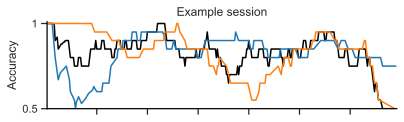

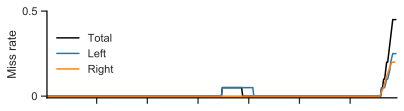

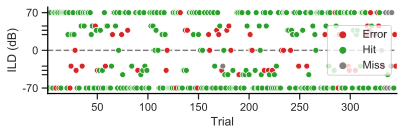

In [13]:
plot_session_trace(df_session, trace='accuracy')
plot_session_trace(df_session, trace='miss')
plot_session_scatter(df_session)

In [14]:
from licks import *

ModuleNotFoundError: No module named 'statsmodels'

In [36]:
# Add lick data to the DataFrame
df = add_lick_data(df)

0.27% of premature lick trials (before response window)
Port1In or Port2In are already lists


In [48]:
# per-session standard deviation for each side
grp = df.groupby("Session").agg(
    std_left=("nLicksLeft", "std"),
    std_right=("nLicksRight", "std")
)

# session with most similar variability between sides
session_id = (grp["std_left"] - grp["std_right"]).abs().idxmin()

C:\Users\Usuario\pv_nmdar_eranet\experiments\2AFC_2\setups\333\sessions\333_stage_training_v2_20220510-091850\333_stage_training_v2_20220510-091850.csv
'Plot 1: accuracy per side' took 0.08 seconds to run
'Plot 2: accuracy repeating vs alternating' took 0.05 seconds to run
'Plot 3: misses' took 0.06 seconds to run
'Plot 4: misses' took 0.03 seconds to run
'Plot 5: peristimulus lick raster' took 3.95 seconds to run
'Plot 6: peristimulus lick histogram (all licks)' took 0.11 seconds to run
'Plot 7: peristimulus lick histogram (first licks)' took 0.07 seconds to run
The script took 7.79 seconds to run 



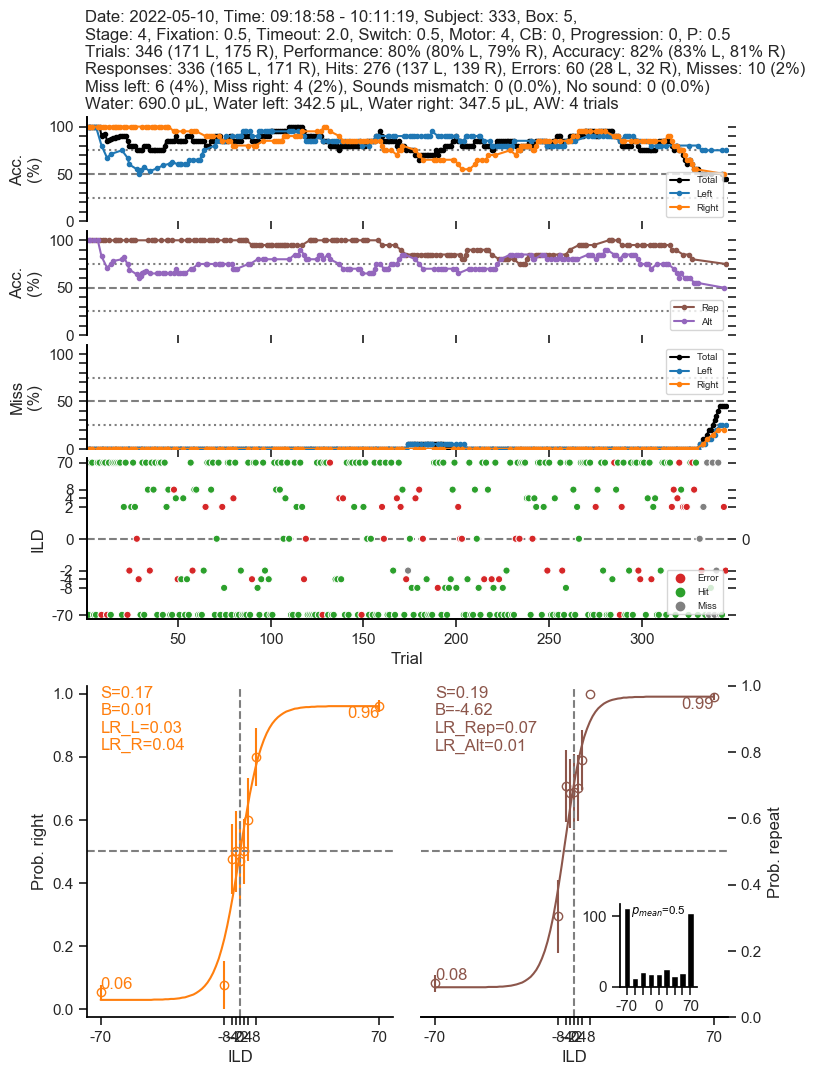

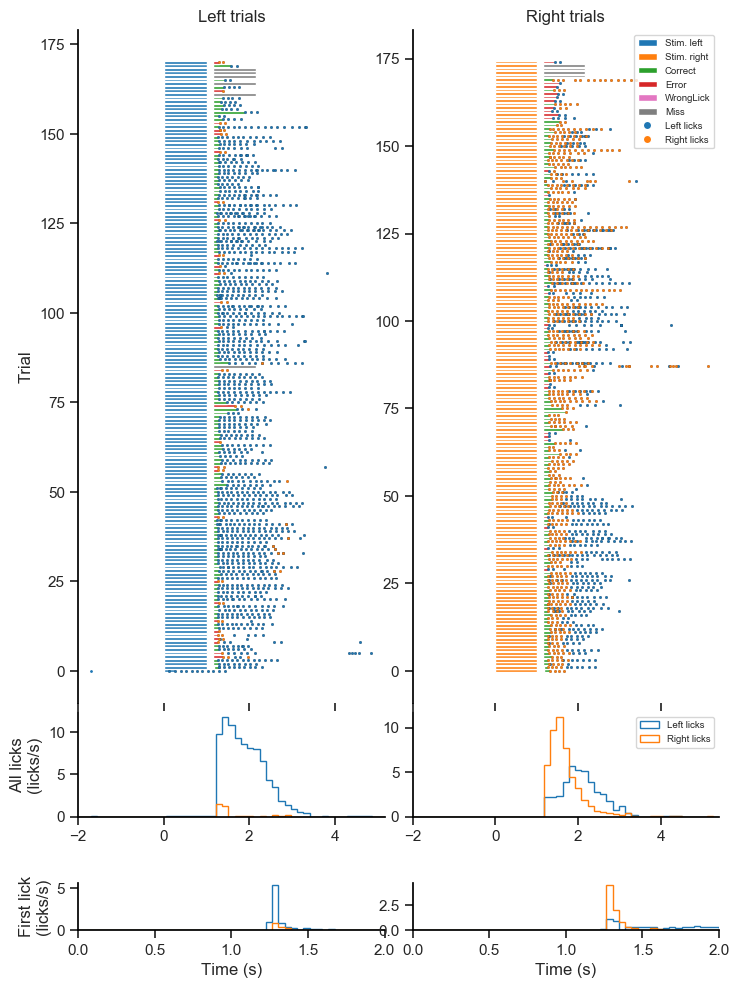

In [17]:
path_session = Path.home() / 'pv_nmdar_eranet' / 'experiments' / '2AFC_2'  / 'setups' / subject / 'sessions'
path_session = (Path(path_session / session_id / session_id)).with_suffix('.csv')
print(path_session)
daily_report_v2(path_session, save=False, send_slack=False)

In [34]:
import os
os.getcwd()
os.chdir(r'C:\Users\Usuario\PycharmProjects\daily_report')
os.getcwd()

'C:\\Users\\Usuario\\PycharmProjects\\daily_report'

In [36]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
# save_notebook_files(notebook_path='notebook.ipynb')

Saved 3 images to notebook_files/
